In [207]:
# 의료 기초 데이터 분석 미니 프로젝트
# NumPy, Pandas, Matplotlib

In [208]:
#==============================================
# [0] 라이브러리 import, 출력 옵션 (선택)
#==============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option('display.width',140)
pd.set_option('display.max_columns',60)
pd.set_option('display.max_rows',200)




# 줄 정렬 옵션
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)


import matplotlib
import matplotlib.font_manager as fm

# 원하는 폰트 파일 경로 문자열로 입력
font_location = 'C:\\Windows\\Fonts\\gulim.ttc'

# 지정한 폰트 파일 경로에서 폰트 추출
fontname = fm.FontProperties(fname=font_location).get_name()

# matplotlib의 전역 폰트 설정 변경
matplotlib.rc('font', family=fontname)


In [209]:
#==============================================
# [1] 데이터 준비
#==============================================


data = {
    "측정일": [
        "2026-02-01","2026-02-01","2026-02-02","2026-02-02","2026-02-03",
        "2026-02-03","2026-02-04","2026-02-04","2026-02-05","2026-02-05",
        "2026-02-06","2026-02-06","2026-02-07","2026-02-07","2026-02-08"
    ],
    "환자ID": [
        "P001","P002","P003","P004","P005",
        "P006","P007","P008","P009","P010",
        "P011","P012","P013","P014","P015"
    ],
    "성별": ["F","M","M","F","F","M","M","F","F","M","F","M","M","F","F"],
    "나이":  [25, 31, 44, np.nan, 52, 39, 28, 33, 47, 61, 29, 42, np.nan, 36, 55],
    "키":    ["162cm","175cm","168cm","160cm","158cm","180cm","172cm","165cm","170cm","177cm","159cm","174cm","169cm","163cm","157cm"],
    "몸무게": ["54kg","78kg","70kg","52kg","60kg","90kg","68kg","58kg","73kg","82kg","50kg","76kg","71kg","57kg","66kg"],
    "SBP(수축기)": [108, 135, 142, 118, 150, 130, 125, 112, 140, 160, 105, 138, 145, 120, 155],
    "DBP(이완기)": [ 70,  88,  92,  75,  95,  85,  80,  72,  90, 100,  68,  89,  96,  78,  97],
    "심박수":      [72,  84,  90,  68,  95,  78,  70,  75,  88,  92,  66,  80,  86,  73,  89],
    "공복혈당":    [92,  110, 125,  98, 130, np.nan, 105,  90, 118, 140,  88, 112, 128, 100, np.nan],
    "흡연":        ["N","Y","Y","N","N","Y","N","N","Y","Y","N","Y","Y","N","N"],
    "운동빈도(주)": [3, 1, 0, 2, np.nan, 1, 4, 2, 1, 0, 5, 1, 0, 3, np.nan],
}

df=pd.DataFrame(data)


In [210]:
#==============================================
# [2] 데이터 탐색
#==============================================

print('=======================================')
print('2) 데이터 탐색')
print('=======================================')

print('\n [head()]')
print(df.head()) # 상위 5개 출력

print('\n [info] (데이터 구조 확인)') # 빈 값이 있는지 (결측치) , 타입 등  -> 데이터 구조 확인
print(df.info())

print('\n[describe] (숫자 컬럼 요약)')
num_cols=['나이','SBP(수축기)','DBP(이완기)','심박수','공복혈당','운동빈도(주)']

print(df[num_cols].describe())


2) 데이터 탐색

 [head()]
       측정일 환자ID 성별  나이     키 몸무게  SBP(수축기)  DBP(이완기)  심박수  공복혈당 흡연  운동빈도(주)
0  2026-02-01   P001    F  25.0  162cm   54kg          108           70      72      92.0    N           3.0
1  2026-02-01   P002    M  31.0  175cm   78kg          135           88      84     110.0    Y           1.0
2  2026-02-02   P003    M  44.0  168cm   70kg          142           92      90     125.0    Y           0.0
3  2026-02-02   P004    F   NaN  160cm   52kg          118           75      68      98.0    N           2.0
4  2026-02-03   P005    F  52.0  158cm   60kg          150           95      95     130.0    N           NaN

 [info] (데이터 구조 확인)
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   측정일       15 non-null     str    
 1   환자ID      15 non-null     str    
 2   성별        15 non-null     str    
 3   나이        13 non-null     float64
 4   키     

In [211]:
#==============================================
# [3] 데이터 정제 및 변환
#==============================================

print('=======================================')
print('3) 데이터 정제 및 변환')
print('=======================================')

# ------------------------------------------------
# 3-1) 타입 변환 : 날짜 문자열 -> datatime
# ------------------------------------------------
# pd.to_datetime() : 문자열을 날짜/시간 타입으로 변환




df['측정일']= pd.to_datetime(df['측정일'])


# ------------------------------------------------
# 3-2) 단위 제거 : "170cm" -> 170, "70kg" -> 70   -> 내용을 대체하는 게 아니라, 추가시켜 놓음 ex) 몸무게(기존 유지), 뭄무게 _kg 을 추가
# ------------------------------------------------
# str.replace() : 문자열 치환 (여기서는 단위 제거)
# astype(int) : 숫자형으로 변환
df['키_cm']=df['키'].str.replace('cm','',regex=False).astype(int)


df['몸무게_kg'] = df['몸무게'].str.replace('kg','',regex=False).astype(int)


# 원본(키, 몸무계) 컬럼은 '문자열' 이라 분석에 불리하므로 
# 보통 숫자형 컬럼(키 _cm ,몸무계 _kg) 만 쓰는 편


# ------------------------------------------------
# 3-3) 결측치 확인
# ------------------------------------------------

print('\n[결측치 계수 확인]')
#print(df.isnull().sum())




# ------------------------------------------------
# 3-4) 결측치 처리 (예시)
# ------------------------------------------------

''' 
결측치 처리 방식은 정답이 1개가 아니라, 상황에 따라 다름
- 나이 : 평균으로 채움
- 공복혈당 : 중앙값으로 채움 (극단 값 영향을 줄이고 싶을 때)
- 운동빈도 : 0으로 채움 (운동 기록이 없으면 0으로 가정하는 경우)
'''

df['나이']=df['나이'].fillna(df['나이'].mean())  # mean : 평균 값 , fillna: 중앙 값
df['공복혈당']=df['공복혈당'].fillna(df['공복혈당'].mean())
df['운동빈도(주)']=df['운동빈도(주)'].fillna(0)

#print(df)
#print(df.isnull().sum())


# ------------------------------------------------
# 3-5) 파생 컬럼 생성 (변환)
# ------------------------------------------------
# BMI= 뭄무게(kg) / 키(m)^2


df['키_m']=df['키_cm'] / 100
df['BMI']=df['몸무게_kg'] / (df['키_m']**2)

# 맥박압(PP) = SBP - DBP(혈관 탄성/압력 차이를 보는 간단 지표)

df['맥박압_PP']=df['SBP(수축기)']-df['DBP(이완기)']

# 평균동맥압(MAP) = (SBP +2*DBP) / 3 (기초적인 참고 지표)
df['평균동맥압_MAP']=df['SBP(수축기)']+2*df['DBP(이완기)']/3

#print(df.head(2))

# ------------------------------------------------
# 3-6) 범주화(카테고리 만들기) : 혈압 단계 분류
# ------------------------------------------------
'''
 기준(간단 버전)
 - 정상 : SBP < 120 그리고 DBP < 80
 - 주의(상승) : SBP 120~129 그리고 DBP < 80
 - 고혈압1기 : SBP 130~139 그리고 DBP 80~89
 - 고혈압2기 : SBP >=140 또는 DBP >= 90
'''

def bp_category(sbp,dbp):
    if(sbp <120) and (dbp< 80):
        return '정상'
    elif(120<=sbp<=129) and (dbp<80):
        return '주의(상승)'
    elif(130<=sbp<=139) and (80<=dbp<=89):
        return '고혈압1기'
    elif(sbp>=140) or (dbp>=90):
        return '고혈압2기'
    else: 
        return '기타'

# apply() : 행 단위로 함수를 적용할 때 자주 사용
# lamba row : 익명 함수 (이름 없는 함수)
# lamba 입력값 : 계산식

df['혈압분류']=df.apply(lambda row: bp_category(row['SBP(수축기)'],row['DBP(이완기)']),axis=1)




# ------------------------------------------------
# 3-7) 범주화 : BMI 단계 분류(간단 예시)
# ------------------------------------------------
'''
BMI 분류
- 저체중 : <18.5
- 정상 : 18.5 ~ 22.9
- 과체중 : 23.0 ~ 24.9
- 비만 : >= 25.0
'''

def bmi_category(bmi):
    if bmi <18.5:
        return '저체중'
    elif bmi <23.0:
        return '정상'
    elif bmi <25.0:
        return '과체중'
    return '비만'
df['BMI분류']=df['BMI'].apply(bmi_category)
  
print('\n[정제 변환 결과 미리보기]')
show_cols = ["측정일","환자ID","성별","나이","키_cm","몸무게_kg","SBP(수축기)","DBP(이완기)","공복혈당","운동빈도(주)","BMI","혈압분류","BMI분류"]
##print(df[show_cols].head(5))



3) 데이터 정제 및 변환

[결측치 계수 확인]

[정제 변환 결과 미리보기]


In [212]:
#==============================================
# [4] 분석
#==============================================

print('=======================================')
print('4) 분석')
print('=======================================')

# ------------------------------------------------
# 4-1) 최고/최저 : BMI가 가장 높은/낮은 사람
# ------------------------------------------------

max_bmi_row=df.loc[df['BMI'].idxmax()]  # 최댓값 위치 반환
min_bmi_row=df.loc[df['BMI'].idxmin()]  # 최솟값 위치 반환

print('\n[BMI 최고]')
print(max_bmi_row[['환자ID','성별','나이','키_cm','몸무게_kg','BMI','BMI분류']])
print('\n[BMI 최저]')
print(min_bmi_row[['환자ID','성별','나이','키_cm','몸무게_kg','BMI','BMI분류']])



# ------------------------------------------------
# 4-2) 혈압 분류별 평균 지표
# ------------------------------------------------
# groupby(): 데이터를 같은 기준으로 묶는 기능
bp_group=df.groupby('혈압분류')[["SBP(수축기)",'DBP(이완기)','맥박압_PP','평균동맥압_MAP','BMI','공복혈당']].mean().sort_values('SBP(수축기)',ascending=False)

print('\n [혈압동류별 평균]')
#print(bp_group)

# ------------------------------------------------
# 4-3) 성별 평균 비교
# ------------------------------------------------
gender_mean=df.groupby('성별')[['SBP(수축기)','DBP(이완기)','심박수','공복혈당','BMI','운동빈도(주)']].mean()
print('\n 성별 평균 비교')
print(gender_mean)

# ------------------------------------------------
# 4-4) 나이대(연령대) 만들기 + 그룹 평균
# ------------------------------------------------
'''
나이대는 분석에서 자주 사용
- pd.cut(): 숫자를 구간으로 나눠 범주형 컬럼 생성
'''

bins=[0,29,39,49,59,120]
labels=['20대','30대','40대','50대','60대 이상']
df['나이대']= pd.cut(df['나이'],bins=bins,labels=labels,right=True) # right= true : 0~29 -> 20대 , 29~39 -> 30대

age_group=df.groupby('나이대')[['SBP(수축기)','DBP(이완기)','공복혈당','BMI']].mean()
print('\n 나이대별 평균')
print(age_group)


# ------------------------------------------------
# 4-5) 상관관계(수치형 컬럼)
# ------------------------------------------------
'''
corr(): 상관계수(-1~1)
-  1에 가까울수록 같이 오르는 경향(양의 상관)       # 키 클수록 뭄무계 크다 (비례)
- -1에 가까울수록 반대로 움직이는 경향(음의 상관)   # 운동량 클수록 몸무계 낮다 (반비례)
-  0에 가까우면 관계가 거의 없다(무상관에 가까움)   
'''
corr_cols=['나이','키_cm','몸무게_kg','SBP(수축기)','DBP(이완기)','공복혈당','운동빈도(주)','BMI','맥박압_PP','평균동맥압_MAP']
corr_df=df[corr_cols].corr()
print('\n [상관관계]')
print(corr_df)

# ------------------------------------------------
# 4-6) 조건 필터링
# ------------------------------------------------
'''
예시 위험군 조건
- 위험 : 고혈압 2기
- 공복혈당 : 126이상(당뇨 기준으로 자주 언급되는 구간)
- BMI : 25이상(비만)

해당 조건 중 하나라도 True면 관심 대상이라고 가정
'''

risk_df=df[
    (df['혈압분류']=='고혈압2기') |
    (df['공복혈당']>=126)   |
    (df['BMI']>=25.0)
].copy()

print('\n [관심 대상 목록]')

print(risk_df[["환자ID", "성별", "나이", "SBP(수축기)", "DBP(이완기)", "혈압분류", "공복혈당", "BMI", "BMI분류", "운동빈도(주)"]])

# ------------------------------------------------
# 4-7) 교차 분석 : 성별 + 혈압분류
# ------------------------------------------------
'''
두 개의 기준을 동시에 비교하는 분석
- 성별에 따라 혈압 분포가 어떻게 다른지 확인
- 단순 평균보다 더 '분포'를 볼 수 있음
'''

# crosstab() : 두 개 이상의 범주형 변수의 관계를 표로 정리하는 함수
cross=pd.crosstab(df['성별'],df['혈압분류'])
print('\n [성별 + 혈압분류 교차 표]')
print(cross)


# ------------------------------------------------
# 4-8) 비율 분석
# ------------------------------------------------
'''
개수보다 비율이 중요할 때가 많음
- 전체 중에서 각 혈압분류가 몇 %인지 확인
'''

# value_counts() : 각 항목이 몇 번 나왔는지 세는 함수
# normalize=True를 넣으면 개수가 아니라 비율로 바꿔줌
# ex ) 정상 : 3/5 = 0.6
# * 100은 비율이 보통 0~1 사이 소수로 나오기 때문에 쉽게 %로 바꾸기 위해서 사용함
bp_ratio=df['혈압분류'].value_counts(normalize=True)*100

print('\n[혈압분류비율]')
print(bp_ratio.round(1))

# ------------------------------------------------
# 4-9) 상위 N명 분석 (Top 분석)
# ------------------------------------------------
'''
특정 기준에서 상위 데이터 확인
-BMI가 높은 사람 상위 3명
-위험군 빠르게 파악 가능
'''
# nlargest(): 데이터에서 값이 가장 큰 상위 N개 뽑는 함수
top3_bmi=df.nlargest(3,"BMI")
print('\n[BMI 상위 3명]')
print(top3_bmi[['환자ID','BMI','BMI분류']])

# ------------------------------------------------
# 4-10) 조건 + 그룹 분석
# ------------------------------------------------
'''
특정 조건을 만족하는 데이터만 따로 분석
- 고혈압 2기 환자만 따로 모아서 성별 평균 비교
'''

ht_df=df[df['혈압분류']=='고혈압2기']
ht_mean=ht_df.groupby('성별')[['BMI','공복혈당']].mean()
print("\n[고혈압2기 환자 - 성별 평균]")
print(ht_mean)

# ------------------------------------------------
# 4-11) 순위(RANK) 만들기
# ------------------------------------------------
'''
데이터에 순서를 부여
-BMI 기준 순위 작성   
'''
# rank() : 데이터의 순위를 매기는 함수 (전체) -> 순위만 매기고, 정렬을 하지 않음, lagest (): 상위 n개만 
df['BMI순위']=df['BMI'].rank(ascending=True) # ascending =True : 작은 값이 위로 ,큰 값은 아래로 
print('\n[BMI 순위만 매기기]') 
# BMI 순위별로 보는 게 아니라 데이터 순서대로 출력
print(df[['환자ID','BMI','BMI순위']])
# BMI 순위별로 출력
print('\n[BMI 순위별로 출력]') 
df_sorted=df.sort_values('BMI순위')
print(df_sorted[['환자ID','BMI','BMI순위']])



# ------------------------------------------------
# 4-12) 위험 점수 만들기
# ------------------------------------------------
'''
조건을 점수화해서 위험도를 표현
조건: 
- 고혈압2기 
- 공복혈당 >=126
- BMI >=25
각 조건마다 1점씩 부여
'''

df['위험점수']=(
(df['혈압분류']=='고혈압2기').astype(int) +
(df['공복혈당']>=126).astype(int) +
(df['BMI']>=25).astype(int) )


print('\n[위험 점수]')
print(df[['환자ID','위험점수']])




4) 분석

[BMI 최고]
환자ID            P006
성별                 M
나이              39.0
키_cm              180
몸무게_kg           90
BMI          27.777778
BMI분류           비만
Name: 5, dtype: object

[BMI 최저]
환자ID            P011
성별                 F
나이              29.0
키_cm              159
몸무게_kg           50
BMI          19.777699
BMI분류           정상
Name: 10, dtype: object

 [혈압동류별 평균]

 성별 평균 비교
      SBP(수축기)  DBP(이완기)     심박수    공복혈당        BMI  운동빈도(주)
성별                                                                          
F      126.000000       80.625  78.250000  103.307692  22.436739           2.0
M      139.285714       90.000  82.857143  118.637363  25.309921           1.0

 나이대별 평균
           SBP(수축기)  DBP(이완기)    공복혈당        BMI
나이대                                                    
20대        112.666667    72.666667   95.000000  21.113076
30대        124.250000    80.750000  102.615385  24.001172
40대        136.600000    88.400000  116.200000  24.067014
50대        152.500000   

5) 시각화


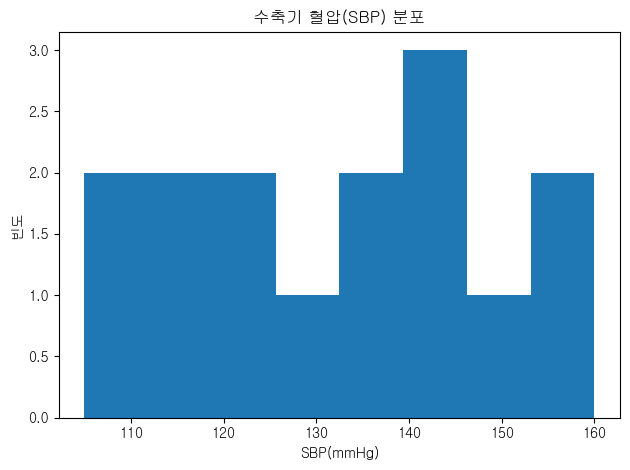

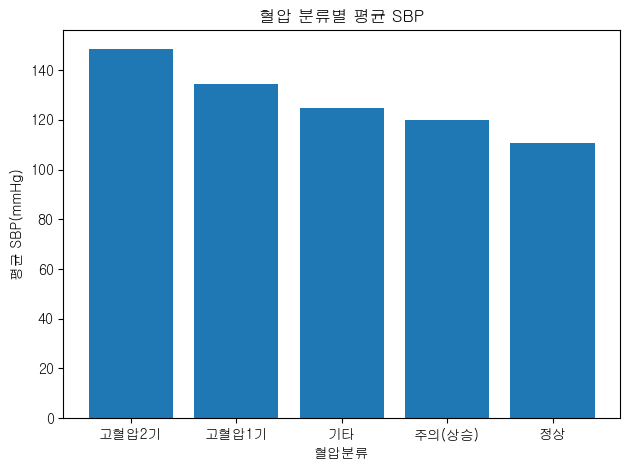

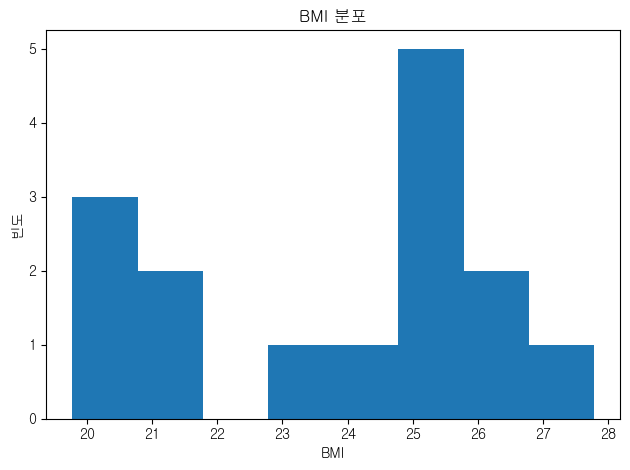

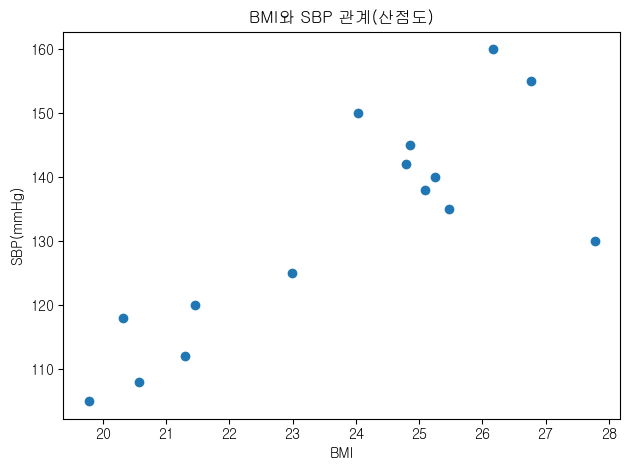

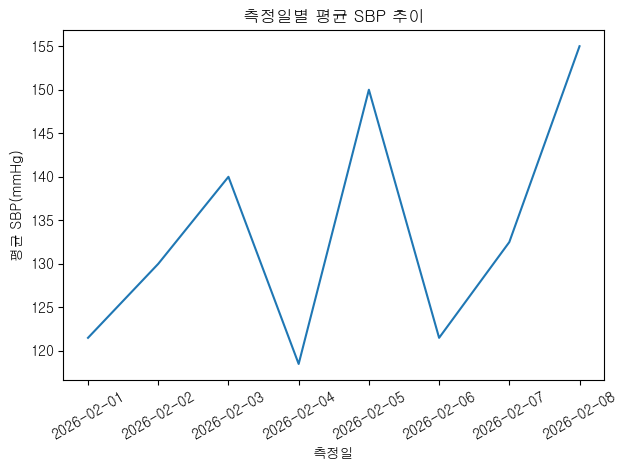

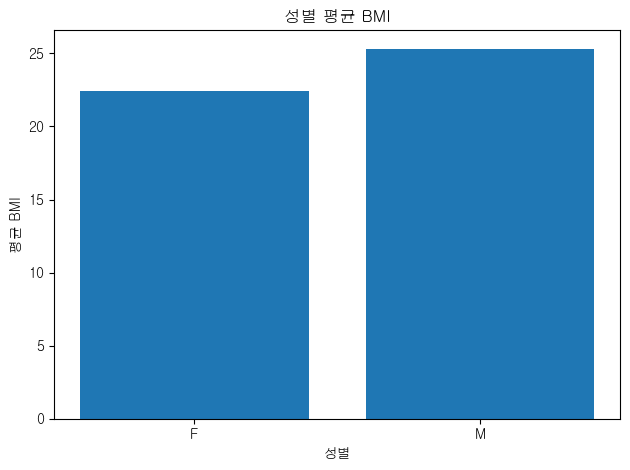

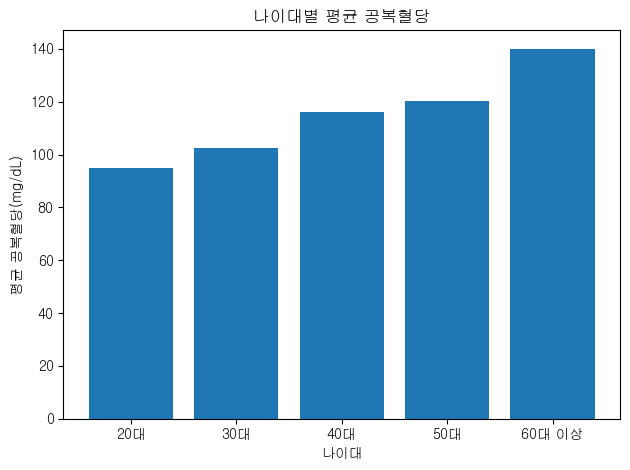

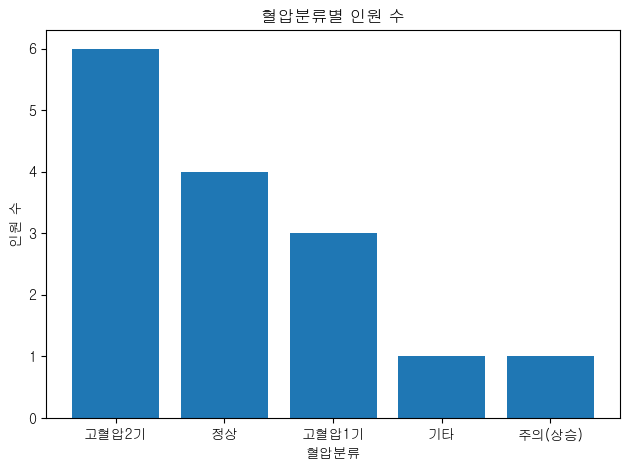

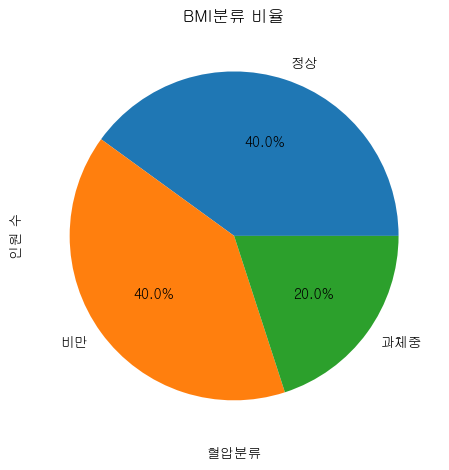

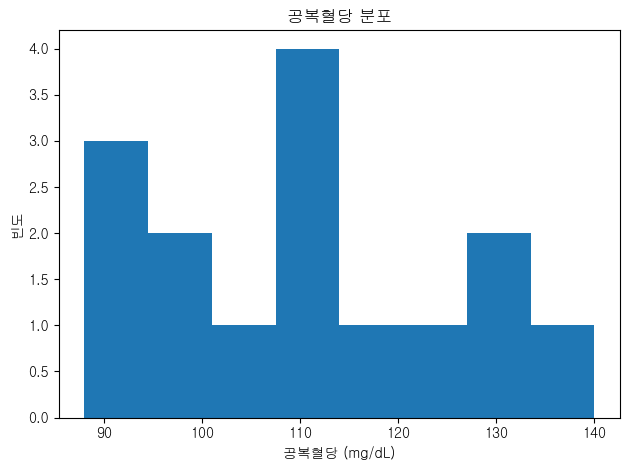

<Figure size 640x480 with 0 Axes>

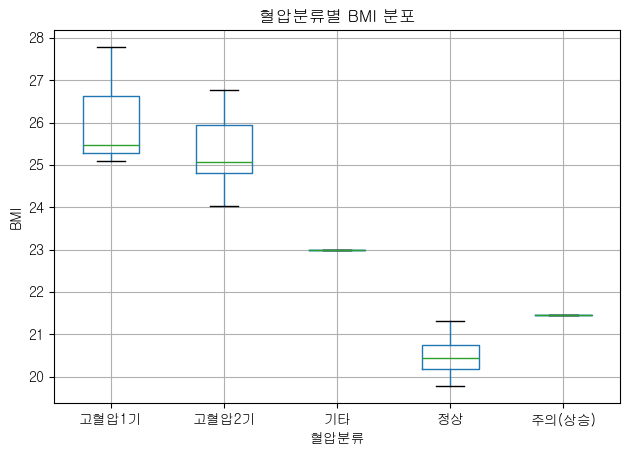

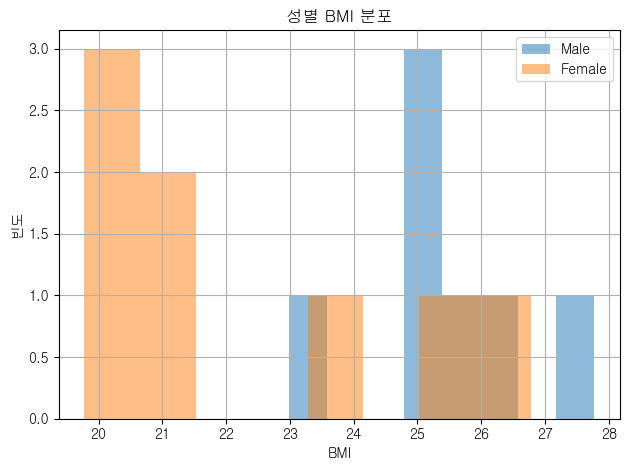

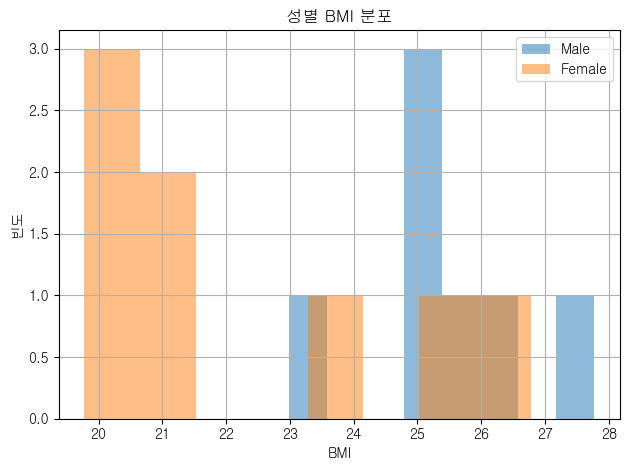

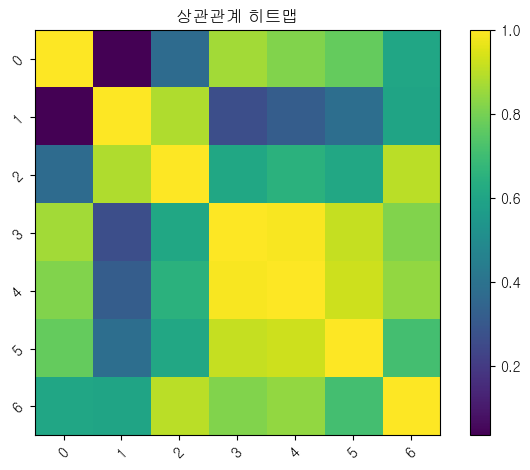

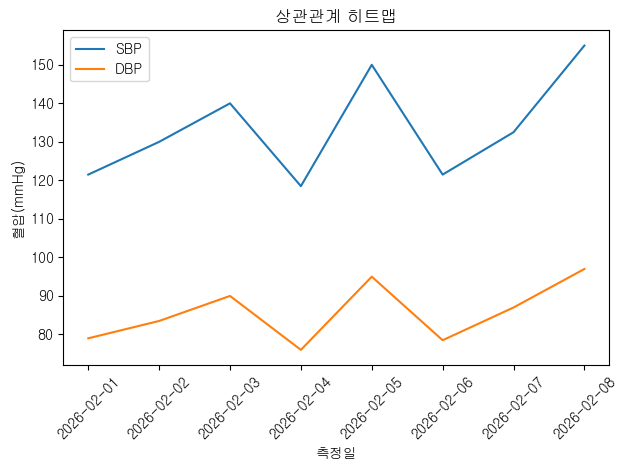

In [213]:
# ------------------------------------------------
# [5] 시각화
# ------------------------------------------------

print("=====================================")
print('5) 시각화')
print("=====================================")

# ------------------------------------------------
# 5-1) 혈압(SBP/DBP) 분포 히스토그램
# ------------------------------------------------

''' 
- 숫자 데이터가 어느 구간에 얼마나 많이 모여 있는지 보여주는 그래프
- bins : 크면 클수록 구간이 촘촘하게 나타남
- 구간 수에 따라 그래프 모양이 달라짐
'''

plt.figure() # 그래프 공간 생성
plt.hist(df['SBP(수축기)'],bins=8)  # 구간 설정
plt.title('수축기 혈압(SBP) 분포') # 그래프 위 제목
plt.xlabel('SBP(mmHg)') # 가로축 의미 설명
plt.ylabel('빈도')      # 세로축 의미 설명
plt.tight_layout()      # 글자가 잘리지 않게 자동 정렬
plt.show()








# ------------------------------------------------
# 5-2) 혈압분류 별 평균 SBP 막대그래프
# ------------------------------------------------
bp_sbp_mean=df.groupby('혈압분류')['SBP(수축기)'].mean().sort_values(ascending=False)

plt.figure() 
plt.bar(bp_sbp_mean.index, bp_sbp_mean.values)  
plt.title('혈압 분류별 평균 SBP')
plt.xlabel('혈압분류') 
plt.ylabel('평균 SBP(mmHg)')      
plt.tight_layout()      
plt.show()




# ------------------------------------------------
# 5-3) BMI 분포 히스토그램
# ------------------------------------------------
plt.figure() 
plt.hist(df['BMI'],bins=8)  
plt.title('BMI 분포')
plt.xlabel('BMI') 
plt.ylabel('빈도')      
plt.tight_layout()      
plt.show()



# ------------------------------------------------
# 5-4) 산점도 : BMI vs SBP
# ------------------------------------------------
''' 
산점도 : 두 개의 숫자 변수 관계를 점으로 표현한 그래프



'''
plt.figure() 
plt.scatter(df['BMI'],df['SBP(수축기)'])  
plt.title('BMI와 SBP 관계(산점도)')
plt.xlabel('BMI') 
plt.ylabel('SBP(mmHg)')      
plt.tight_layout()      
plt.show()





# ------------------------------------------------
# 5-5) 측정일 기준 SBP 추이 (날짜별 평균)
# ------------------------------------------------
date_sbp=df.groupby('측정일')['SBP(수축기)'].mean()

plt.figure() 
plt.plot(date_sbp.index,date_sbp.values)
plt.title('측정일별 평균 SBP 추이')
plt.xlabel('측정일') 
plt.ylabel('평균 SBP(mmHg)') 
plt.xticks(rotation=30)     # x축 눈금(ticks) : 30도 화전 -> 글자가 길 때 회전시킴
plt.tight_layout()      
plt.show()



# ------------------------------------------------
# 5-6) 성별 평균 BMI 비교
# ------------------------------------------------

gender_bmi_mean=df.groupby('성별')['BMI'].mean()

plt.figure() 
plt.bar(gender_bmi_mean.index,gender_bmi_mean.values)
plt.title('성별 평균 BMI')
plt.xlabel('성별') 
plt.ylabel('평균 BMI') 
plt.tight_layout()      
plt.show()

# ------------------------------------------------
# 5-7) 나이대별 평균 공복할당
# ------------------------------------------------

ages_glucose_mean=df.groupby('나이대')['공복혈당'].mean()

plt.figure() 
plt.bar(ages_glucose_mean.index,ages_glucose_mean.values)
plt.title('나이대별 평균 공복혈당')
plt.xlabel('나이대') 
plt.ylabel('평균 공복혈당(mg/dL)') 
plt.tight_layout()      
plt.show()



# ------------------------------------------------
# 5-8) 혈압분류 인원 수 
# ------------------------------------------------

bp_count=df['혈압분류'].value_counts()

plt.figure() 
plt.bar(bp_count.index,bp_count.values)
plt.title('혈압분류별 인원 수')
plt.xlabel('혈압분류') 
plt.ylabel('인원 수') 
plt.tight_layout()      
plt.show()



# ------------------------------------------------
# 5-9) BMI 분류 인원 수 (파이차트) 
# ------------------------------------------------

bmi_count=df['BMI분류'].value_counts()

plt.figure()
plt.pie(
    bmi_count.values,  # 인원 수
    labels=bmi_count.index,   # 정상, 과체중 등
    autopct='%1.1f%%'        # 비율


)


plt.title('BMI분류 비율')
plt.xlabel('혈압분류') 
plt.ylabel('인원 수') 
plt.tight_layout()      
plt.show()





# ------------------------------------------------
# 5-10) 공복혈당 분포 히스토그램 
# ------------------------------------------------



plt.figure()
plt.hist(df['공복혈당'],bins=8)


plt.title('공복혈당 분포')
plt.xlabel('공복혈당 (mg/dL)') 
plt.ylabel('빈도') 
plt.tight_layout()      
plt.show()



# ------------------------------------------------
# 5-11) 혈압분류별 BMI 분포 (박스플롯)
# ------------------------------------------------
'''
- 평균이 아니라 분포를 보여줌
- 이상치 확인 가능  -> 중앙값, 사분위 수
'''


plt.figure()
df.boxplot(column='BMI',by='혈압분류')


plt.title('혈압분류별 BMI 분포')
plt.suptitle('')
plt.xlabel('혈압분류') 
plt.ylabel('BMI') 
plt.tight_layout()      
plt.show()



# ------------------------------------------------
# 5-12) 성별 BMI
# ------------------------------------------------



plt.figure()
df[df['성별']=='M']['BMI'].hist(alpha=0.5,bins=8)   # alpha =0.5 반투명 -> 겹쳐서 그릴 때 사용
df[df['성별']=='F']['BMI'].hist(alpha=0.5,bins=8)


plt.title('성별 BMI 분포')
plt.xlabel('BMI') 
plt.ylabel('빈도')
plt.legend(['Male','Female'])   # 오른쪽 위 부분에 작은 설명
plt.tight_layout()      
plt.show()




# ------------------------------------------------
# 5-13) 성별 BMI
# ------------------------------------------------

plt.figure()
df[df['성별']=='M']['BMI'].hist(alpha=0.5,bins=8)   # alpha =0.5 반투명 -> 겹쳐서 그릴 때 사용
df[df['성별']=='F']['BMI'].hist(alpha=0.5,bins=8)


plt.title('성별 BMI 분포')
plt.xlabel('BMI') 
plt.ylabel('빈도')
plt.legend(['Male','Female'])   # 오른쪽 위 부분에 작은 설명
plt.tight_layout()      
plt.show()





# ------------------------------------------------
# 5-14) 상관 관계 히트맵
# ------------------------------------------------
'''
히트맵: 값의 크기를 색으로 표현하는 그래프
값이 클수록 진한색, 값이 작을수록 연한색
'''


corr_cols=['나이','키_cm','몸무게_kg','SBP(수축기)','DBP(이완기)','공복혈당','BMI']
corr=df[corr_cols].corr()
plt.figure()
plt.imshow(corr) 
plt.colorbar()
plt.xticks(range(len(corr_cols)),rotation=45)
plt.yticks(range(len(corr_cols)),rotation=45)

plt.title('상관관계 히트맵')
plt.tight_layout()      
plt.show()


# ------------------------------------------------
# 5-15) SBP vs DBP
# ------------------------------------------------

date_sbp=df.groupby('측정일')['SBP(수축기)'].mean()
date_dbp=df.groupby('측정일')['DBP(이완기)'].mean()



plt.figure()
plt.plot(date_sbp.index,date_sbp.values) 
plt.plot(date_dbp.index,date_dbp.values) 
plt.title('SBP VS DBP 추이 비교')
plt.xlabel('측정일')
plt.ylabel('혈압(mmHg)')
plt.xticks(rotation=45)
plt.legend(['SBP','DBP'])
plt.title('상관관계 히트맵')
plt.tight_layout()      
plt.show()


In [214]:
# ------------------------------------------------
# [6] 인사이트 자동 요약 ,  데이터 가공 -> 데이터 시각화 -> 쓸모 있는 결론 (인사이트)
# ------------------------------------------------

print("=====================================")
print('6) 인사이트 자동 요약')
print("=====================================")

# ------------------------------------------------
# 6-1) 혈압분류 비율
# ------------------------------------------------

bp_counts=df['혈압분류'].value_counts() # 혈압분류 개수 세기
bp_ratio=(bp_counts/len(df))*100        # 비율 계산

print('\n [혈압분류 분포(개수)]')
print(bp_counts)


print('\n [혈압분류 분포(비율%)]')
print(bp_counts.round(1)) # 소수 점 한 자리까지만 표시

# ------------------------------------------------
# 6-2) 위험 신호 : 공복혈당 평균과 126 이상 비율
# ------------------------------------------------
mean_glu= df['공복혈당'].mean()
high_glu_ratio=(df['공복혈당']>=126).mean() * 100 
print(f'\n [공복혈당 평균]: {mean_glu: .2f} mg/dL')
print(f'\n [공복혈당 126 이상 비율]: {high_glu_ratio: .1f} mg/dL')


# ------------------------------------------------
# 6-3) 운동 빈도와 주유 지표 관계
# ------------------------------------------------
# 상관계수만으로 원인/결론을 단정하면 안되지만, 흐름을 보는 연습에는 좋음
corr_exercise_sbp=df['운동빈도(주)'].corr(df['SBP(수축기)'])
corr_exercise_bmi=df['운동빈도(주)'].corr(df['BMI'])

print(f'\n [운동빈도 vs SBP 상관계수] {corr_exercise_sbp: .2f}' )
print(f'\n [운동빈도 vs BMI] {corr_exercise_bmi: .2f}' )

# ------------------------------------------------
# 6-4) 전략/제안 3줄
# ------------------------------------------------
strategy=[]
# 혈압2기 비율 기반 코멘트
ht2_ratio=(df['혈압분류']=='고혈압2기').mean() *100

if(ht2_ratio>=30) :
    strategy.append('고혈압2기 비율이 높은 편이라, 생활습관(운동/체중/염분)관련 교육 및 추적 관리가 필요합니다.')
else:
    strategy.append('고혈압2기 비율이 과도하게 높진 않지만, 고혈압1기 이상에 대한 예방 안내가 유효합니다.')

# BMI 비만 비율 코멘트
obesity_ratio=(df['BMI분류']=='비만').mean() * 100 
strategy.append(f'BMI 기준 비만 비율이 {obesity_ratio: .1f}로 확인되어, 체중 관리(식습관 +운동) 프로그램을 고려할 수 있습니다.')

# 혈당 고위험 비율 코멘트
if high_glu_ratio > 20:
    strategy.append('공복혈당 126 이상 비율이 꽤 있어, 혈당 관련 추가 검사/상담 연계를 고려할 수 있습니다.')
else:
    strategy.append('공복혈당 고위험 비율이 높진 않지만, 식습관/활동량 관련 기본 가이드를 제공하면 좋습니다.')

print('\n [제안 3줄]')
for s in strategy:
    print(f'- {s}')




# ------------------------------------------------
# 6-5) 위험 점수 기반 위험군 요약
# ------------------------------------------------
''' 
- 위험점수 2 이상 -> 고위험군
'''

high_risk=df[df['위험점수']>=2]
high_risk_ratio=(len(high_risk)/len(df))*100

print(f'\n [고위험군 비율(위험점수 2이상)] {high_risk_ratio: .2f}')
print('[고위험군 목록]')
print(high_risk[['환자ID','BMI','공복혈당','혈압분류','위험점수']])

# ------------------------------------------------
# 6-6) 최상위 위험 대상 Top 3
# ------------------------------------------------
''' 
가장 위험한 사람 추출
- 위험점수 기준
- 동일하면 BMI 높은 순
'''
top_lisk=df.sort_values(['위험점수','BMI'],ascending=False).head(3)
print('\n[최상위 위험 대상 top 3]')
print(top_lisk[['환자ID','위험점수','BMI','공복혈당','혈압분류']])

# ------------------------------------------------
# 6-7) 전체 건강 상태 등급 평가
# ------------------------------------------------
''' 
데이터 전체를 하나의 결과로 요약
기준:
-고위험군 비율
-혈당 위험 비율
'''

if (high_risk_ratio>30) or (high_glu_ratio>30):
    health_level='위험'
elif (high_risk_ratio>15) or (high_glu_ratio>15):
    health_level='주의'
else:
    health_level='양호'

print(f'\n [전체 건강 상태 평가] -> {health_level}')

6) 인사이트 자동 요약

 [혈압분류 분포(개수)]
혈압분류
고혈압2기     6
정상          4
고혈압1기     3
기타          1
주의(상승)    1
Name: count, dtype: int64

 [혈압분류 분포(비율%)]
혈압분류
고혈압2기     6
정상          4
고혈압1기     3
기타          1
주의(상승)    1
Name: count, dtype: int64

 [공복혈당 평균]:  110.46 mg/dL

 [공복혈당 126 이상 비율]:  20.0 mg/dL

 [운동빈도 vs SBP 상관계수] -0.86

 [운동빈도 vs BMI] -0.76

 [제안 3줄]
- 고혈압2기 비율이 높은 편이라, 생활습관(운동/체중/염분)관련 교육 및 추적 관리가 필요합니다.
- BMI 기준 비만 비율이  40.0로 확인되어, 체중 관리(식습관 +운동) 프로그램을 고려할 수 있습니다.
- 공복혈당 고위험 비율이 높진 않지만, 식습관/활동량 관련 기본 가이드를 제공하면 좋습니다.

 [고위험군 비율(위험점수 2이상)]  33.33
[고위험군 목록]
   환자ID        BMI    공복혈당   혈압분류  위험점수
4    P005  24.034610  130.000000  고혈압2기         2
8    P009  25.259516  118.000000  고혈압2기         2
9    P010  26.173833  140.000000  고혈압2기         3
12   P013  24.859074  128.000000  고혈압2기         2
14   P015  26.775934  110.461538  고혈압2기         2

[최상위 위험 대상 top 3]
   환자ID  위험점수        BMI    공복혈당   혈압분류
9    P010         3  26.173833  140.000000  고혈압2기
14   P015         2  26.775934  110.

In [216]:
# ------------------------------------------------
# [7] 저장
# ------------------------------------------------

print("=====================================")
print('7) 저장')
print("=====================================")


''' 
to_csv() 저장
- index=False : 행 인덱스 (0,1,2 ...) f를 파일에 저장하지 않음
- encoding="utf=8-sig" :액셀에서 한글 깨짐 방지(윈도우 환경에서  유용)
'''


# ------------------------------------------------
# 7-1) 고위험군 데이터 따로 저장
# ------------------------------------------------

high_risk.to_csv('high_risk_pathients.csv',index=False,encoding='utf=8-sig')
print('고위험군 파일 저장 완료')


# ------------------------------------------------
# 7-2) 분석 요약 결과 저장
# ------------------------------------------------

summary={
    '전체 인원' : len(df),
    '고위험군 비율(%)' : round(high_risk_ratio,1),
    '공복혈당 평균' : round(mean_glu,2),
    '공복혈당 위험 비율(%)' : round(high_glu_ratio,1),
    '전체 건강 상태' : health_level,

}
summary_df=pd.DataFrame([summary])
summary_df.to_csv('analysis_summary.csv',index=False,encoding='utf=8-sig')
print('분석 요약 파일 저장 완료')



# ------------------------------------------------
# 7-3) 통합 저장
# ------------------------------------------------
df.to_csv('medical_basic_analysis.csv',index=False,encoding='utf=8-sig')
print("통합 파일 저장 완료")
print("프로젝트 종료")



7) 저장
고위험군 파일 저장 완료
분석 요약 파일 저장 완료
통합 파일 저장 완료
프로젝트 종료
